In [1]:
# EDF（European Data Format，欧洲数据格式）是生理信号领域最通用的开源数据存储标准之一，
# 尤其在睡眠监测（PSG）、脑电（EEG）、心电（ECG）等多导生理记录中被广泛采用，
# 具有通用、兼容的特点，其设计哲学就是简单、开放、够用

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 加载本地文件，preload=True 表示预加载，在读取时就把全部数据载入内存
raw = mne.io.read_raw_edf("../data/SC4001E0-PSG.edf", preload=True)

# 读取睡眠分期注释文件（Hypnogram）
annot = mne.read_annotations("../data/SC4001EC-Hypnogram.edf")

# 把注释绑定到 Raw 对象上
raw.set_annotations(annot)

Extracting EDF parameters from ../data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\74453\AppData\Local\Temp\ipykernel_15812\3968316912.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("../data/SC4001E0-PSG.edf", preload=True)
C:\Users\74453\AppData\Local\Temp\ipykernel_15812\3968316912.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf("../data/SC4001E0-PSG.edf", preload=True)
C:\Users\74453\AppData\Local\Temp\ipykernel_15812\3968316912.py:2: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf("../data/SC4001E0-PSG.edf", preload=True)
C:\Users\74453\AppData\Local\Temp\ipykernel_15812\3968316912.py:8: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [6]:
# 获取原始数据中的事件
events_from_annot, event_dict = mne.events_from_annotations(raw)
print(event_dict)
print(events_from_annot)

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
{np.str_('Sleep stage 1'): 1, np.str_('Sleep stage 2'): 2, np.str_('Sleep stage 3'): 3, np.str_('Sleep stage 4'): 4, np.str_('Sleep stage ?'): 5, np.str_('Sleep stage R'): 6, np.str_('Sleep stage W'): 7}
[[      0       0       7]
 [3063000       0       1]
 [3075000       0       2]
 [3114000       0       3]
 [3117000       0       2]
 [3120000       0       3]
 [3135000       0       4]
 [3138000       0       3]
 [3144000       0       4]
 [3150000       0       3]
 [3153000       0       4]
 [3165000       0       3]
 [3168000       0       4]
 [3180000       0       7]
 [3183000       0       3]
 [3189000       0       2]
 [3195000       0       3]
 [3207000       0       4]
 [3210000       0       3]
 [3213000       0       4]
 [3225000       0       2]
 [3246000      

In [8]:
# 获取事件
custom_mapping = {'Sleep stage 3': 4, 'Sleep stage 4': 4}
events_from_annot, event_dict = mne.events_from_annotations(raw, event_id=custom_mapping)
print(event_dict)
print(events_from_annot)

Used Annotations descriptions: [np.str_('Sleep stage 3'), np.str_('Sleep stage 4')]
{np.str_('Sleep stage 3'): 4, np.str_('Sleep stage 4'): 4}
[[3114000       0       4]
 [3120000       0       4]
 [3135000       0       4]
 [3138000       0       4]
 [3144000       0       4]
 [3150000       0       4]
 [3153000       0       4]
 [3165000       0       4]
 [3168000       0       4]
 [3183000       0       4]
 [3195000       0       4]
 [3207000       0       4]
 [3210000       0       4]
 [3213000       0       4]
 [3246000       0       4]
 [3255000       0       4]
 [3285000       0       4]
 [3294000       0       4]
 [3300000       0       4]
 [3312000       0       4]
 [3327000       0       4]
 [3333000       0       4]
 [3339000       0       4]
 [3342000       0       4]
 [3351000       0       4]
 [3543000       0       4]
 [3570000       0       4]
 [3594000       0       4]
 [3726000       0       4]
 [3846000       0       4]
 [3852000       0       4]
 [3858000       0   

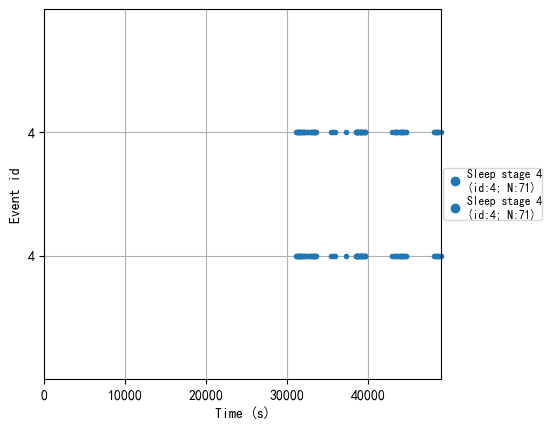

In [9]:
# 绘制事件图
# 睡眠分期事件的时间分布图
# events_from_annot : 事件数组 (n_events, 3)，每行是 [采样点索引, 0, 事件编码]
# event_dict        : 阶段名称到编码的映射，如 {'Sleep stage 3': 4, 'Sleep stage 4': 4}
# sfreq             : 采样频率，用于将采样点索引转换为物理时间（秒）
fig = mne.viz.plot_events(events_from_annot, event_id=event_dict, sfreq=raw.info['sfreq'])
plt.show()

Not setting metadata
71 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 71 events and 71 original time points ...
0 bad epochs dropped
Not setting metadata
71 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\epochs.py:382: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  this_axes_dict["evoked"].figure.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


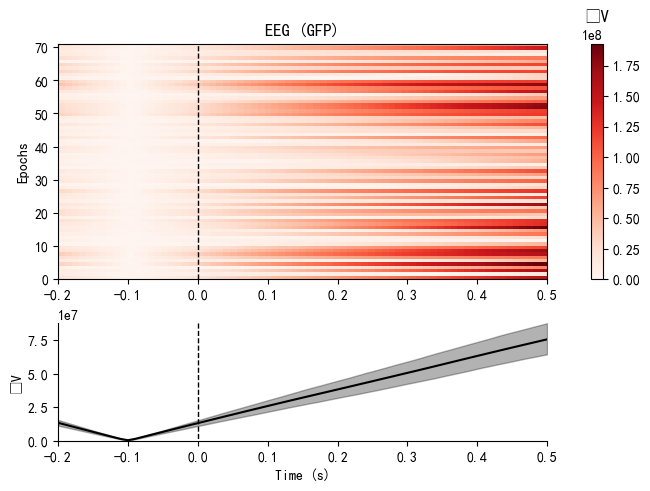

[<Figure size 640x480 with 3 Axes>]

In [10]:
# 根据事件标记将原始连续数据切分为多个 epoch（试次/时段）
epochs = mne.Epochs(raw, events_from_annot, event_dict)
# 以热力图（heatmap / image plot）形式绘制所有 epoch 的数据
epochs.plot_image()

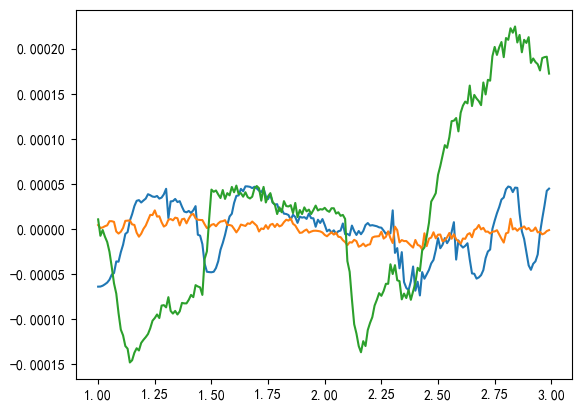

In [11]:
# 从 Raw 对象的 info 字典中读取采样频率（单位：Hz）
sfreq = raw.info['sfreq']

# 提取数据：选取前 3 个通道（索引 0~2），时间范围从第 1 秒到第  3 秒
# int(sfreq*1) 和 int(sfreq*3) 将物理时间转换为对应的采样点索引
# data 形状为 (3, n_times)，times 为对应的时间轴（单位：秒）
data, times = raw[:3, int(sfreq*1):int(sfreq*3)]

plt.plot(times, data.T)
plt.show()

In [20]:
#